In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from typing import Tuple, List, Dict, Any

# Контрольная работа. Вариант 2

## № 1

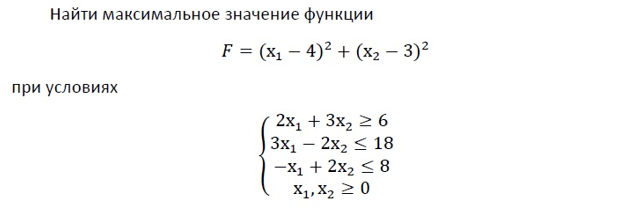

In [11]:
def objective_function(x: np.ndarray) -> float:
    """
    Целевая функция для минимизации.
    Так как нам нужен максимум F, мы возвращаем -F.
    x: Массив [x1, x2]
    """
    x1, x2 = x[0], x[1]
    f_val = (x1 - 4)**2 + (x2 - 3)**2
    return -f_val  # Инвертируем для минимизации

def solve_nlp_multistart() -> Tuple[np.ndarray, float]:
    """
    Решает задачу NLP используя метод SLSQP (Sequential Least SQuares Programming)
    с подходом multi-start для избежания локальных оптимумов.
    """
    # Границы переменных: x1 >= 0, x2 >= 0
    bounds = ((0, None), (0, None))

    # Ограничения (Constraints) для SciPy приводятся к виду: f(x) >= 0
    # 1: 2*x1 + 3*x2 >= 6      =>  2*x1 + 3*x2 - 6 >= 0
    # 2: 3*x1 - 2*x2 <= 18     => -3*x1 + 2*x2 + 18 >= 0
    # 3: -x1 + 2*x2 <= 8       =>  x1 - 2*x2 + 8 >= 0
    constraints: List[Dict[str, Any]] = [
        {'type': 'ineq', 'fun': lambda x: 2*x[0] + 3*x[1] - 6},
        {'type': 'ineq', 'fun': lambda x: -3*x[0] + 2*x[1] + 18},
        {'type': 'ineq', 'fun': lambda x: x[0] - 2*x[1] + 8}
    ]

    # Стартовые точки для алгоритма (Multi-start)
    # Выбираем точки разбросанные по предполагаемой области
    initial_guesses = np.array([
        [0.0, 2.0], 
        [10.0, 10.0], 
        [5.0, 0.0], 
        [0.0, 4.0]
    ])

    best_x = None
    best_f = float('inf')

    for x0 in initial_guesses:
        res = minimize(
            objective_function, 
            x0, 
            method='SLSQP', 
            bounds=bounds, 
            constraints=constraints
        )
        
        if res.success and res.fun < best_f:
            best_f = res.fun
            best_x = res.x

    # Возвращаем найденную точку и реальное (положительное) значение максимума F
    return best_x, -best_f

# Выполнение поиска
optimal_point, max_value = solve_nlp_multistart()
print(f"Оптимальная точка (x1, x2): [{optimal_point[0]:.4f}, {optimal_point[1]:.4f}]")
print(f"Максимальное значение функции F: {max_value:.4f}")

Оптимальная точка (x1, x2): [13.0000, 10.5000]
Максимальное значение функции F: 137.2500


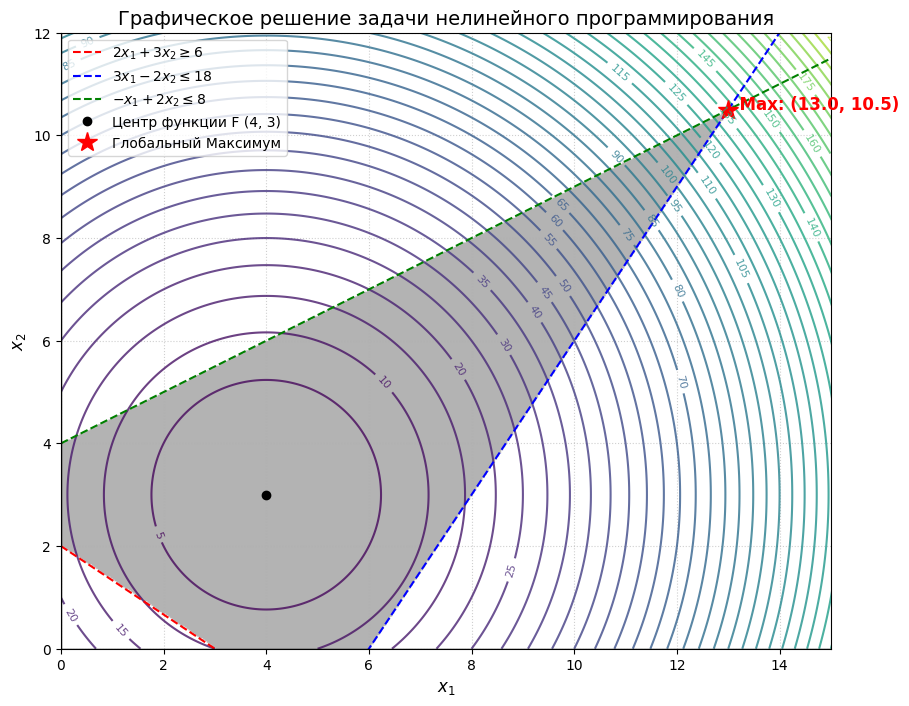

In [12]:
def plot_solution(opt_point: np.ndarray):
    """
    Строит график допустимого множества (Feasible region),
    линий уровня целевой функции и отмечает оптимальную точку.
    """
    # Настройка сетки для графика
    x1_val = np.linspace(0, 16, 400)
    x2_val = np.linspace(0, 12, 400)
    X1, X2 = np.meshgrid(x1_val, x2_val)

    # Вычисление значений целевой функции на сетке
    Z = (X1 - 4)**2 + (X2 - 3)**2

    # Создание маски для допустимого множества (Feasible Region)
    # В np.where мы логически пересекаем все неравенства
    feasible_region = (
        (2*X1 + 3*X2 >= 6) & 
        (3*X1 - 2*X2 <= 18) & 
        (-X1 + 2*X2 <= 8) & 
        (X1 >= 0) & 
        (X2 >= 0)
    )

    plt.figure(figsize=(10, 8))

    # 1. Заливка допустимого множества
    plt.imshow(
        feasible_region.astype(int), 
        extent=(X1.min(), X1.max(), X2.min(), X2.max()), 
        origin='lower', 
        cmap='Greys', 
        alpha=0.3
    )

    # 2. Отрисовка контуров (линий уровня) целевой функции
    # Это окружности с центром в (4, 3)
    contours = plt.contour(X1, X2, Z, levels=47, cmap='viridis', alpha=0.8)
    plt.clabel(contours, inline=True, fontsize=8)

    # 3. Границы ограничений (линии)
    # x2 = (6 - 2x1) / 3
    plt.plot(x1_val, (6 - 2*x1_val)/3, 'r--', label=r'$2x_1 + 3x_2 \geq 6$')
    # x2 = (3x1 - 18) / 2  => x2 >= 1.5*x1 - 9
    plt.plot(x1_val, (3*x1_val - 18)/2, 'b--', label=r'$3x_1 - 2x_2 \leq 18$')
    # x2 = (8 + x1) / 2 => x2 <= 0.5*x1 + 4
    plt.plot(x1_val, (8 + x1_val)/2, 'g--', label=r'$-x_1 + 2x_2 \leq 8$')

    # 4. Центр целевой функции (4, 3)
    plt.plot(4, 3, 'ko', markersize=6, label='Центр функции F (4, 3)')

    # 5. Оптимальная точка
    plt.plot(opt_point[0], opt_point[1], 'r*', markersize=15, label='Глобальный Максимум')
    
    # Аннотация оптимальной точки
    plt.annotate(
        f"  Max: ({opt_point[0]:.1f}, {opt_point[1]:.1f})", 
        (opt_point[0], opt_point[1]),
        fontsize=12, fontweight='bold', color='red'
    )

    # Оформление графика
    plt.xlim(0, 15)
    plt.ylim(0, 12)
    plt.xlabel(r'$x_1$', fontsize=12)
    plt.ylabel(r'$x_2$', fontsize=12)
    plt.title('Графическое решение задачи нелинейного программирования', fontsize=14)
    plt.axhline(0, color='black', linewidth=1)
    plt.axvline(0, color='black', linewidth=1)
    plt.legend(loc='upper left')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()

# Вызов функции отрисовки
plot_solution(optimal_point)

## № 2

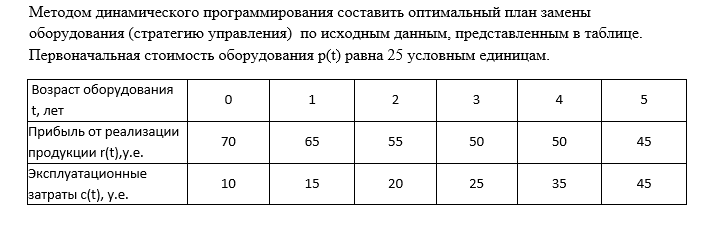

In [13]:
import pandas as pd
import numpy as np
from typing import Dict, Tuple, List

In [14]:
def solve_equipment_replacement() -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Решает задачу оптимальной замены оборудования методом динамического программирования.
    Возвращает две таблицы (DataFrame):
    1. Матрица максимальных прибылей (f_k(t))
    2. Матрица оптимальных стратегий (Keep/Replace)
    """
    # Исходные данные
    P = 25
    r = {0: 70, 1: 65, 2: 55, 3: 50, 4: 50, 5: 45}
    c = {0: 10, 1: 15, 2: 20, 3: 25, 4: 35, 5: 45}
    
    N_years = 5
    max_age = 5
    
    # Инициализация структур данных
    # Строки - возраст t (от 0 до 5)
    # Столбцы - год планирования k (от 1 до 5)
    f = np.zeros((max_age + 1, N_years + 2)) # +2 для удобства индексации (учитываем k=6 как 0)
    strategy = np.full((max_age + 1, N_years + 1), "", dtype=object)
    
    # Обратный ход (Backward Induction)
    for k in range(N_years, 0, -1):
        # Доход от замены (одинаков для любого возраста t, так как мы покупаем новое)
        # Мы платим P, получаем r(0), тратим c(0). К следующему году возраст станет 1.
        replace_value = r[0] - c[0] - P + f[1, k + 1]
        
        for t in range(max_age + 1):
            # Если мы сохраняем, оборудование стареет на 1 год (t -> t+1)
            # Если t=5, и мы сохраняем, возраст становится 6. 
            # Так как данных для t=6 нет, предположим, что эксплуатация невозможна (штраф),
            # либо мы просто обязаны заменить. В классической задаче обычно заставляют заменить.
            if t < max_age:
                keep_value = r[t] - c[t] + f[t + 1, k + 1]
            else:
                keep_value = float('-inf') # Форсируем замену при достижении максимального возраста
                
            # Выбор оптимального решения
            if keep_value > replace_value:
                f[t, k] = keep_value
                strategy[t, k] = "Сохранить"
            elif replace_value > keep_value:
                f[t, k] = replace_value
                strategy[t, k] = "Заменить"
            else:
                f[t, k] = keep_value
                strategy[t, k] = "Любое (С/З)" # Альтернативный оптимум
                
    # Оформление результатов в виде таблиц pandas для красоты
    years_cols = [f"Год {k}" for k in range(1, N_years + 1)]
    age_idx = [f"Возраст {t}" for t in range(max_age + 1)]
    
    df_profits = pd.DataFrame(f[:, 1:N_years+1], index=age_idx, columns=years_cols)
    df_strategy = pd.DataFrame(strategy[:, 1:N_years+1], index=age_idx, columns=years_cols)
    
    return df_profits, df_strategy

def trace_optimal_path(df_strategy: pd.DataFrame, start_age: int = 0) -> List[str]:
    """
    Восстанавливает оптимальный путь с первого года для заданного начального возраста.
    """
    path = []
    current_age = start_age
    
    for year in range(1, df_strategy.shape[1] + 1):
        col_name = f"Год {year}"
        action = df_strategy.loc[f"Возраст {current_age}", col_name]
        
        step_info = f"Год {year} (возраст {current_age}): {action}"
        path.append(step_info)
        
        if "Сохранить" in action:
            current_age += 1
        else: # Если Заменить или Любое (выберем Заменить для простоты пути)
            current_age = 1
            
    return path

# Выполнение и вывод
profits, strategies = solve_equipment_replacement()

print("Матрица максимальных прибылей f_k(t):")
display(profits)

print("\nМатрица оптимальных стратегий:")
display(strategies)

print("\nОптимальный план (если начинаем с нового оборудования, возраст 0):")
optimal_plan = trace_optimal_path(strategies, start_age=0)
for step in optimal_plan:
    print(step)

Матрица максимальных прибылей f_k(t):


,Год 1,Год 2,Год 3,Год 4,Год 5
Возраст 0,230.0,195.0,145.0,110.0,60.0
Возраст 1,220.0,170.0,135.0,85.0,50.0
Возраст 2,205.0,170.0,120.0,85.0,35.0
Возраст 3,205.0,170.0,120.0,85.0,35.0
Возраст 4,205.0,170.0,120.0,85.0,35.0
Возраст 5,205.0,170.0,120.0,85.0,35.0



Матрица оптимальных стратегий:


,Год 1,Год 2,Год 3,Год 4,Год 5
Возраст 0,Сохранить,Сохранить,Сохранить,Сохранить,Сохранить
Возраст 1,Сохранить,Любое (С/З),Сохранить,Любое (С/З),Сохранить
Возраст 2,Любое (С/З),Заменить,Любое (С/З),Заменить,Любое (С/З)
Возраст 3,Заменить,Заменить,Заменить,Заменить,Заменить
Возраст 4,Заменить,Заменить,Заменить,Заменить,Заменить
Возраст 5,Заменить,Заменить,Заменить,Заменить,Заменить



Оптимальный план (если начинаем с нового оборудования, возраст 0):
Год 1 (возраст 0): Сохранить
Год 2 (возраст 1): Любое (С/З)
Год 3 (возраст 1): Сохранить
Год 4 (возраст 2): Заменить
Год 5 (возраст 1): Сохранить


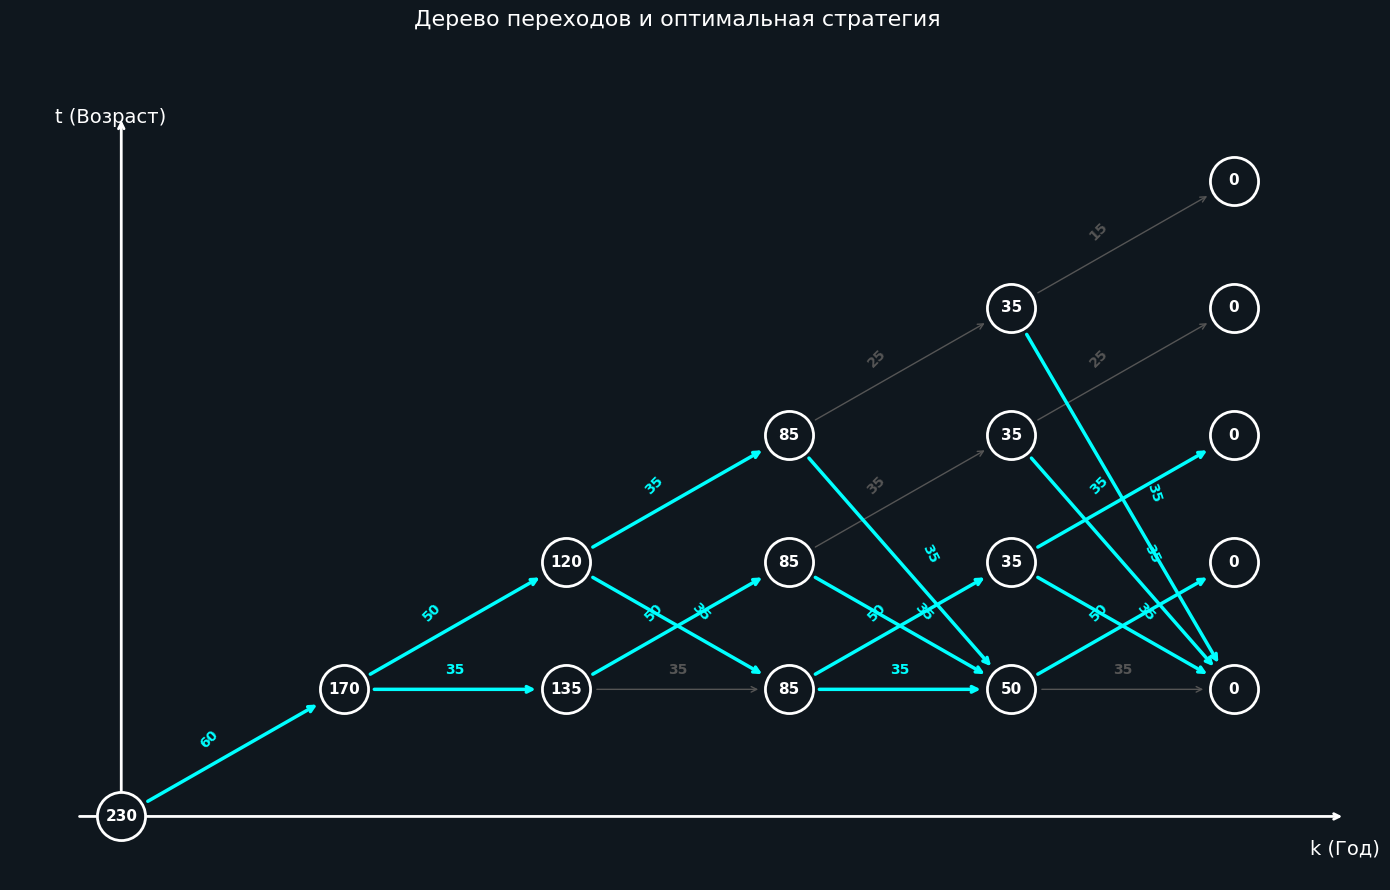

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import math

# --- 1. Исходные данные ---
r = {0: 70, 1: 65, 2: 55, 3: 50, 4: 50, 5: 45}
c = {0: 10, 1: 15, 2: 20, 3: 25, 4: 35, 5: 45}
P = 25
replace_reward = r[0] - c[0] - P  # Фиксированная прибыль в год замены: 70 - 10 - 25 = 35
N = 5 # Горизонт планирования

# --- 2. Динамическое программирование (Обратный ход) ---
dp = {} # Словарь для мемоизации: (k, t) -> max_profit

def get_max_profit(k: int, t: int) -> int:
    """Рекурсивная функция для вычисления f_k(t)."""
    if k == N + 1: # Терминальное состояние (конец 5-го года)
        return 0
    if (k, t) in dp:
        return dp[(k, t)]
    
    keep_val = (r[t] - c[t]) + get_max_profit(k + 1, t + 1)
    replace_val = replace_reward + get_max_profit(k + 1, 1)
    
    dp[(k, t)] = max(keep_val, replace_val)
    return dp[(k, t)]

# Определяем достижимые состояния, если начинаем с t=0 в k=1
reachable_states = {1: [0]}
for k in range(1, N + 1):
    # Следующие возможные возраста: либо постарело на 1 (t+1), либо заменили (стало 1)
    reachable_states[k + 1] = list(set([t + 1 for t in reachable_states[k]] + [1]))

# Собираем ребра графа (переходы)
edges = []
for k in range(1, N + 1):
    for t in reachable_states[k]:
        current_val = get_max_profit(k, t)
        
        keep_reward = r[t] - c[t]
        keep_val = keep_reward + get_max_profit(k + 1, t + 1)
        is_keep_opt = (keep_val == current_val)
        
        replace_val = replace_reward + get_max_profit(k + 1, 1)
        is_replace_opt = (replace_val == current_val)
        
        # Для t=0 действие "заменить" бессмысленно (заменяем новое на новое), 
        # обе стрелки ведут в (k+1, 1), поэтому рисуем только "Сохранить"
        if t == 0:
            edges.append({'from': (k, t), 'to': (k+1, t+1), 'reward': keep_reward, 'optimal': is_keep_opt})
        else:
            edges.append({'from': (k, t), 'to': (k+1, t+1), 'reward': keep_reward, 'optimal': is_keep_opt})
            edges.append({'from': (k, t), 'to': (k+1, 1), 'reward': replace_reward, 'optimal': is_replace_opt})

# --- 3. Визуализация графа ---
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(14, 9))
fig.patch.set_facecolor('#0f171e')
ax.set_facecolor('#0f171e')

# Отрисовка осей
ax.annotate("", xy=(N + 1.5, 0), xytext=(0.8, 0), arrowprops=dict(arrowstyle="->", color='white', lw=2))
ax.annotate("", xy=(1, N + 0.5), xytext=(1, -0.2), arrowprops=dict(arrowstyle="->", color='white', lw=2))
ax.text(N + 1.5, -0.3, "k (Год)", color='white', fontsize=14, ha='center')
ax.text(0.7, N + 0.5, "t (Возраст)", color='white', fontsize=14, va='center')

# Отрисовка ребер (стрелок)
for edge in edges:
    k1, t1 = edge['from']
    k2, t2 = edge['to']
    color = '#00ffff' if edge['optimal'] else '#555555' # Циановый для оптимальных путей
    lw = 2.5 if edge['optimal'] else 1.0
    zorder = 2 if edge['optimal'] else 1
    
    # Стрелка
    ax.annotate("", xy=(k2, t2), xytext=(k1, t1), 
                arrowprops=dict(arrowstyle="->", color=color, lw=lw, shrinkA=22, shrinkB=22), zorder=zorder)
    
    # Текст на ребре
    mx, my = (k1 + k2) / 2, (t1 + t2) / 2
    length = math.hypot(1, t2 - t1)
    nx, ny = -(t2 - t1) / length, 1 / length # Нормаль к вектору
    offset = 0.15 # Смещение текста от линии
    
    angle = np.degrees(np.arctan2(t2 - t1, 1))
    if angle < -90 or angle > 90: angle += 180 # Предотвращаем текст вверх ногами
        
    ax.text(mx + nx*offset, my + ny*offset, str(edge['reward']), color=color, 
            rotation=angle, ha='center', va='center', fontsize=10, fontweight='bold', zorder=zorder)

# Отрисовка узлов
for k, states in reachable_states.items():
    for t in states:
        val = get_max_profit(k, t)
        # Круг узла
        ax.scatter(k, t, s=1200, facecolors='#0f171e', edgecolors='white', linewidth=2, zorder=5)
        # Значение f_k(t) внутри круга
        ax.text(k, t, str(val), color='white', ha='center', va='center', fontsize=11, fontweight='bold', zorder=6)

# Настройка отображения
ax.set_xlim(0.5, N + 1.5)
ax.set_ylim(-0.5, N + 1.0)
ax.set_xticks(range(1, N + 2))
ax.set_yticks(range(0, N + 1))
ax.axis('off') # Скрываем стандартные рамки и деления
plt.title("Дерево переходов и оптимальная стратегия", color='white', fontsize=16, pad=20)
plt.tight_layout()
plt.show()